In [1]:
# Imports
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import cv2
import warnings

from pathlib import Path
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from keras.preprocessing.image import ImageDataGenerator
from keras import applications
from keras.models import Sequential, load_model, Model
from keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D, Flatten, Dense, Dropout
from keras.callbacks import ModelCheckpoint, LearningRateScheduler, EarlyStopping, ReduceLROnPlateau, TensorBoard
from keras import optimizers, losses, activations, models
from keras.layers import Convolution2D, Dense, Input, Flatten, Dropout, MaxPooling2D, BatchNormalization, GlobalAveragePooling2D, Concatenate

In [2]:
# Settings
warnings.filterwarnings('ignore')
BATCH_SIZE = 64
IMAGE_SIZE = 224

In [3]:
# Data generator with data augmentation for the training set
train_generator = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

# Data generator without data augmentation for the validation and test sets
valid_test_generator = ImageDataGenerator(rescale=1./255)

In [4]:
# Load data
download_dir = Path("./animals/")

train_data_dir = download_dir/'train'
valid_data_dir = download_dir/'validation'
test_data_dir = download_dir/'test'

traingen = train_generator.flow_from_directory(train_data_dir,
                                               target_size=(IMAGE_SIZE, IMAGE_SIZE),
                                               class_mode='categorical',
                                               subset='training',
                                               color_mode="rgb",
                                               batch_size=BATCH_SIZE, 
                                               shuffle=True,
                                               seed=42)

validgen = valid_test_generator.flow_from_directory(valid_data_dir,
                                              target_size=(IMAGE_SIZE, IMAGE_SIZE),
                                              class_mode='categorical',
                                              color_mode="rgb",
                                              batch_size=BATCH_SIZE)

testgen = valid_test_generator.flow_from_directory(test_data_dir,
                                              target_size=(IMAGE_SIZE, IMAGE_SIZE),
                                              class_mode=None,
                                              color_mode="rgb",
                                              batch_size=1,
                                              shuffle=False)

Found 14308 images belonging to 50 classes.
Found 500 images belonging to 50 classes.
Found 50 images belonging to 50 classes.


In [5]:
# Get class names
x, y = next(traingen)
a = traingen.class_indices
class_names = list(a.keys())

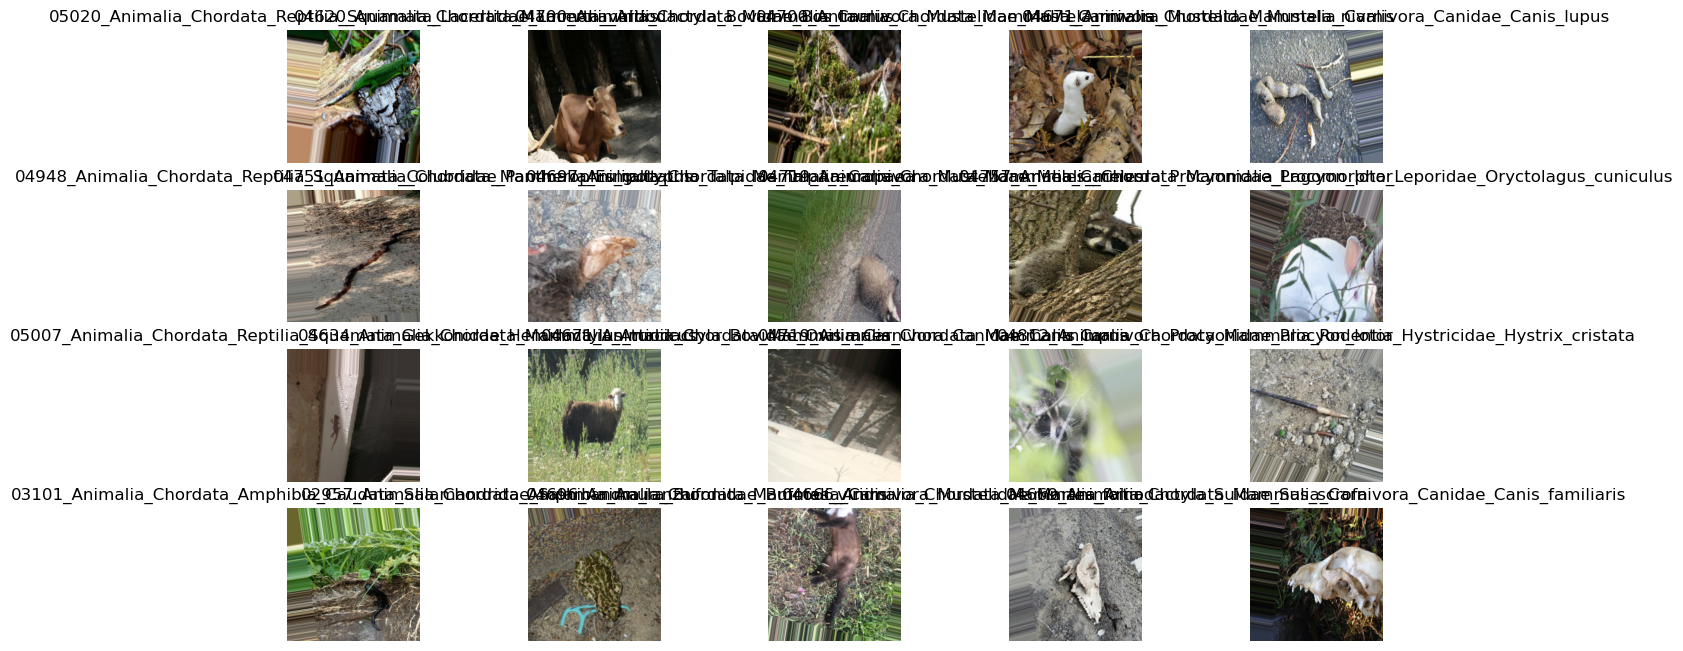

In [6]:
# Plot examples
def plot_images(img, labels):
    plt.figure(figsize=[15, 10])
    for i in range(20):
        plt.subplot(5, 5, i+1)
        plt.imshow(img[i])
        plt.title(class_names[np.argmax(labels[i])])
        plt.axis('off')

plot_images(x, y)

In [7]:
# Params
n_classes = 50
n_steps = traingen.samples // BATCH_SIZE
n_val_steps = validgen.samples // BATCH_SIZE
n_epochs = 40

In [8]:
# Build Model VGG16
base_model = applications.VGG16(weights='imagenet', 
                                include_top=False, 
                                input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3))
base_model.trainable = False

add_model = Sequential()
add_model.add(base_model)
add_model.add(Flatten())
add_model.add(Dense(4096, activation='relu'))
add_model.add(Dropout(0.5))
add_model.add(Dense(4096, activation='relu'))
add_model.add(Dropout(0.5))
add_model.add(Dense(n_classes, activation='softmax'))

model = add_model

2023-04-25 18:40:25.393353: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2023-04-25 18:40:25.393691: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Metal device set to: Apple M1

systemMemory: 8.00 GB
maxCacheSize: 2.67 GB



In [9]:
# Use a smaller learning rate for fine-tuning
optimizer = optimizers.Adam(lr=1e-4)
model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 7, 7, 512)         14714688  
                                                                 
 flatten (Flatten)           (None, 25088)             0         
                                                                 
 dense (Dense)               (None, 4096)              102764544 
                                                                 
 dropout (Dropout)           (None, 4096)              0         
                                                                 
 dense_1 (Dense)             (None, 4096)              16781312  
                                                                 
 dropout_1 (Dropout)         (None, 4096)              0         
                                                                 
 dense_2 (Dense)             (None, 50)                2

In [10]:
# Callbacks

early_stopping = EarlyStopping(patience=15, restore_best_weights=True)

# Save the best model during training
model_checkpoint = ModelCheckpoint('best_model.h5', save_best_only=True, monitor='val_accuracy', mode='max')

# Reduce learning rate when the validation loss plateaus
reduce_lr_on_plateau = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=10, verbose=1, mode='min')

# Fit model
history = model.fit(traingen,
    steps_per_epoch=n_steps,
    validation_data=validgen,
    validation_steps=n_val_steps,
    epochs=n_epochs,
    callbacks=[early_stopping, model_checkpoint, reduce_lr_on_plateau])

Epoch 1/40


2023-04-25 18:40:26.718579: W tensorflow/tsl/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz
2023-04-25 18:40:27.012229: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


223/223 [==============================] - ETA: 0s - loss: 3.9218 - accuracy: 0.0448

2023-04-25 18:45:09.392985: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


223/223 [==============================] - 293s 1s/step - loss: 3.9218 - accuracy: 0.0448 - val_loss: 3.5718 - val_accuracy: 0.0893 - lr: 1.0000e-04
Epoch 2/40
223/223 [==============================] - 291s 1s/step - loss: 3.5837 - accuracy: 0.0837 - val_loss: 3.2805 - val_accuracy: 0.1116 - lr: 1.0000e-04
Epoch 3/40
223/223 [==============================] - 288s 1s/step - loss: 3.3909 - accuracy: 0.1193 - val_loss: 3.0974 - val_accuracy: 0.1674 - lr: 1.0000e-04
Epoch 4/40
223/223 [==============================] - 288s 1s/step - loss: 3.2493 - accuracy: 0.1509 - val_loss: 2.9814 - val_accuracy: 0.1652 - lr: 1.0000e-04
Epoch 5/40
223/223 [==============================] - 289s 1s/step - loss: 3.1409 - accuracy: 0.1688 - val_loss: 2.8821 - val_accuracy: 0.2143 - lr: 1.0000e-04
Epoch 6/40
223/223 [==============================] - 289s 1s/step - loss: 3.0660 - accuracy: 0.1884 - val_loss: 2.8296 - val_accuracy: 0.2344 - lr: 1.0000e-04
Epoch 7/40
223/223 [==============================]

In [11]:
# Save model
model.save("model_vgg16.h5")

In [10]:
# import tensorflow as tf
model = load_model("model_vgg16.h5")

Metal device set to: Apple M1

systemMemory: 8.00 GB
maxCacheSize: 2.67 GB



2023-04-26 19:53:05.519788: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2023-04-26 19:53:05.520250: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [12]:
# Store results
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

Text(0.5, 1.0, '\nTraining and Validation Accuracy. \nTrain Accuracy:0.36260882019996643\nValidation Accuracy: 0.3191964328289032')

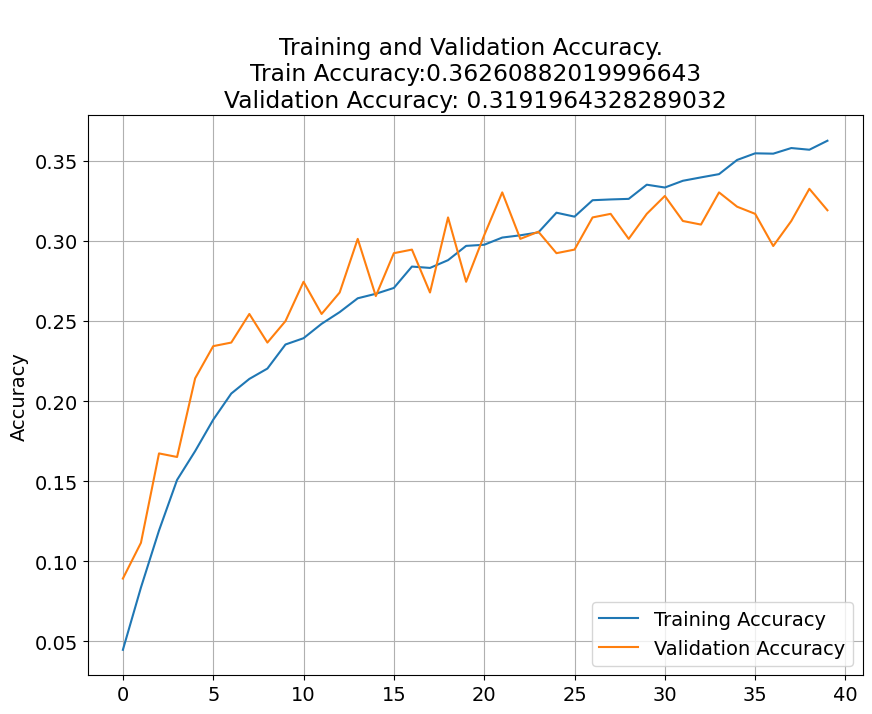

In [13]:
# Plot results

# Accuracy
plt.figure(figsize=(10, 16))
plt.rcParams['figure.figsize'] = [16, 9]
plt.rcParams['font.size'] = 14
plt.rcParams['axes.grid'] = True
plt.rcParams['figure.facecolor'] = 'white'
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.title(f'\nTraining and Validation Accuracy. \nTrain Accuracy:{str(acc[-1])}\nValidation Accuracy: {str(val_acc[-1])}')

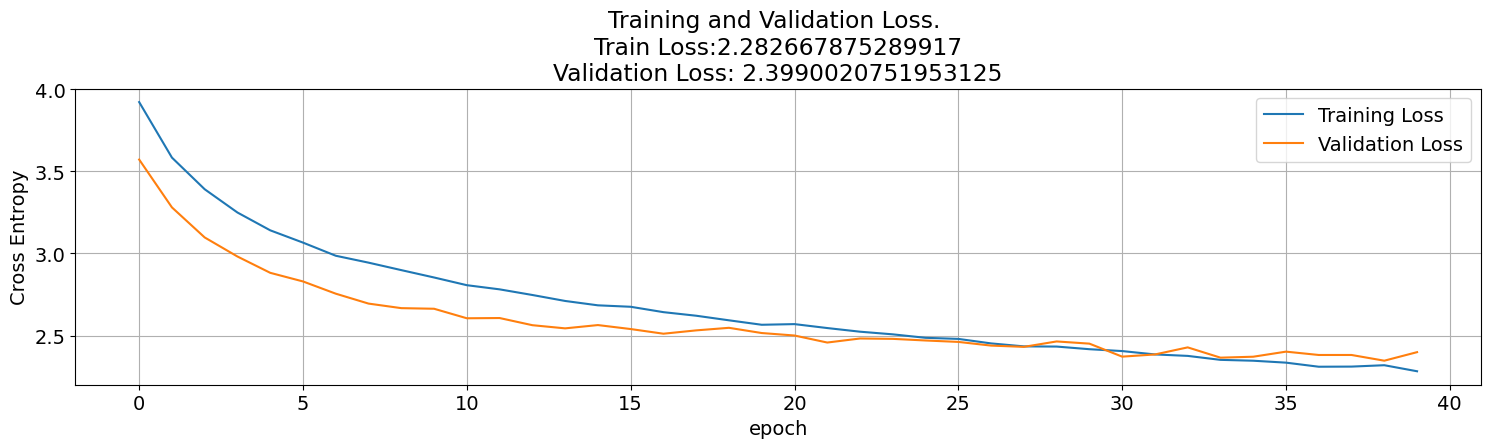

In [14]:
# Loss
plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('Cross Entropy')
plt.title(f'Training and Validation Loss. \nTrain Loss:{str(loss[-1])}\nValidation Loss: {str(val_loss[-1])}')
plt.xlabel('epoch')
plt.tight_layout(pad=3.0)
plt.show()

In [11]:
# Model evaluation on test data
true_classes = testgen.classes
class_indices = traingen.class_indices
class_indices = dict((v, k) for k, v in class_indices.items())
preds = model.predict(testgen)
pred_classes = np.argmax(preds, axis=1)

2023-04-26 19:53:12.487411: W tensorflow/tsl/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz
2023-04-26 19:53:12.570755: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


50/50 [==============================] - 2s 34ms/step


In [12]:
# Accuracy score
acc_score = accuracy_score(true_classes, pred_classes)
print(f"VGG16 Model Accuracy : {acc_score * 100:.2f}%")

VGG16 Model Accuracy : 50.00%


In [13]:
# Confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(true_classes, pred_classes))


Confusion Matrix:
[[1 0 0 ... 0 0 0]
 [0 1 0 ... 0 0 0]
 [0 0 1 ... 0 0 0]
 ...
 [0 0 0 ... 1 0 0]
 [0 0 0 ... 0 1 0]
 [0 0 0 ... 0 0 1]]


In [14]:
# Classification report
print("\nClassification Report:")
print(classification_report(true_classes, pred_classes, target_names=class_names))


Classification Report:
                                                                               precision    recall  f1-score   support

             02957_Animalia_Chordata_Amphibia_Anura_Bufonidae_Bufotes_viridis       0.50      1.00      0.67         1
                  02983_Animalia_Chordata_Amphibia_Anura_Hylidae_Hyla_arborea       1.00      1.00      1.00         1
             02992_Animalia_Chordata_Amphibia_Anura_Hylidae_Hyla_meridionalis       1.00      1.00      1.00         1
         03038_Animalia_Chordata_Amphibia_Anura_Ranidae_Pelophylax_ridibundus       1.00      1.00      1.00         1
                  03045_Animalia_Chordata_Amphibia_Anura_Ranidae_Rana_italica       0.00      0.00      0.00         1
               03048_Animalia_Chordata_Amphibia_Anura_Ranidae_Rana_temporaria       1.00      1.00      1.00         1
03097_Animalia_Chordata_Amphibia_Caudata_Salamandridae_Ichthyosaura_alpestris       0.50      1.00      0.67         1
       03100_Animalia_C

the model performed exceptionally well (with precision, recall, and f1-score of 1.00), while for others, it failed to classify correctly (with scores of 0.00). This indicates that the model might need further improvements or tuning to handle the classes with lower scores more effectively.